# **Modelo Predictivo de Precipitaciones en el Valle de Aburrá**


## Proyecto de Grado

Pablo Gómez Mutis

## **1) Preprocesamiento**

### Importar librerías



In [1]:
import pandas as pd
import numpy as np

### Cargar el dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Proyecto de grado/Estacion_pluviometrica_24_2014-03-03_2025-01-31.csv")

df.head()

,codigo,fecha_hora,p1,p2,calidad
0,24,2014-03-03 13:38:21,0.0,0.0,1
1,24,2014-03-03 13:39:21,0.0,0.0,1
2,24,2014-03-03 13:40:21,0.0,0.0,1
3,24,2014-03-03 13:41:21,0.0,0.0,1
4,24,2014-03-03 13:42:21,0.0,0.0,1


In [4]:
df_preprocessed = df.copy()

### Transformar columna "fecha_hora" a formato *datetime*

In [5]:
df_preprocessed['fecha_hora'] = pd.to_datetime(df_preprocessed['fecha_hora'])
df_preprocessed.drop('codigo', axis=1, inplace=True)

df_preprocessed.head()

,fecha_hora,p1,p2,calidad
0,2014-03-03 13:38:21,0.0,0.0,1
1,2014-03-03 13:39:21,0.0,0.0,1
2,2014-03-03 13:40:21,0.0,0.0,1
3,2014-03-03 13:41:21,0.0,0.0,1
4,2014-03-03 13:42:21,0.0,0.0,1


### Establecer periodo de 01-01-2022 hasta 01-01-2025 (3 años)

In [6]:
print(f"Primera fecha: {df_preprocessed['fecha_hora'].min()}")
print(f"Última fecha: {df_preprocessed['fecha_hora'].max()}")

Primera fecha: 2014-03-03 13:38:21
Última fecha: 2025-01-31 23:59:00


In [7]:
start_date = '2022-01-01'
end_date = '2024-12-31 23:59:59'
df_preprocessed = df_preprocessed[(df_preprocessed['fecha_hora'] >= start_date) & (df_preprocessed['fecha_hora'] <= end_date)]

print(f"Dataset filtrado desde: {df_preprocessed['fecha_hora'].min()}")
print(f"Dataset filtrado hasta: {df_preprocessed['fecha_hora'].max()}")
display(df_preprocessed.head())

Dataset filtrado desde: 2022-01-01 00:00:00
Dataset filtrado hasta: 2024-12-31 23:59:00


,fecha_hora,p1,p2,calidad
3869746,2022-01-01 00:00:00,0.0,0.0,1
3869747,2022-01-01 00:01:00,0.0,0.0,1
3869748,2022-01-01 00:02:00,0.0,0.0,1
3869749,2022-01-01 00:03:00,0.0,0.0,1
3869750,2022-01-01 00:04:00,0.0,0.0,1


### Transformar valores negativos (errores) a cero

In [8]:
df_preprocessed[['p1', 'p2']] = df_preprocessed[['p1', 'p2']].clip(lower=0)

### Simplificar etiquetas entre datos confiables y datos no confiables / no obtenidos

Los datos no confiables y no obtenidos tienen varias subdivisiones. Para simplificar su modelización, se asigna "0" como etiqueta universal para ellos.

In [9]:
df_preprocessed['calidad'] = (df_preprocessed['calidad'] == 1).astype(int)
conteo = df_preprocessed['calidad'].value_counts()
print(conteo)

calidad
1    1526059
0      18947
Name: count, dtype: int64


### Selección del pluviómetro *(p1)*

In [10]:
df_preprocessed.drop('p2', axis=1, inplace=True)
df_preprocessed.head()

,fecha_hora,p1,calidad
3869746,2022-01-01 00:00:00,0.0,1
3869747,2022-01-01 00:01:00,0.0,1
3869748,2022-01-01 00:02:00,0.0,1
3869749,2022-01-01 00:03:00,0.0,1
3869750,2022-01-01 00:04:00,0.0,1


### Establecer *fecha_hora* como índice

In [11]:
df_preprocessed = df_preprocessed.set_index('fecha_hora')
df_preprocessed.head()

,p1,calidad
fecha_hora,,
2022-01-01 00:00:00,0.0,1
2022-01-01 00:01:00,0.0,1
2022-01-01 00:02:00,0.0,1
2022-01-01 00:03:00,0.0,1
2022-01-01 00:04:00,0.0,1


## **2) Modelos de imputación**

### Imputación LightGBM

Total ventanas limpias creadas: 740
Train size: 518
Valid size: 111
Test size : 111

Métricas TRAIN
MAE : 0.042469
RMSE: 0.078175

Métricas VALIDATION
MAE : 0.041119
RMSE: 0.063265

Métricas TEST (independiente)
MAE : 0.04305
RMSE: 0.068252


/tmp/ipython-input-834330420.py:118: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df["p1"].resample("1H").mean()
/tmp/ipython-input-834330420.py:119: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imp_1h = df_lightgbm["p1_imputed"].resample("1H").mean()


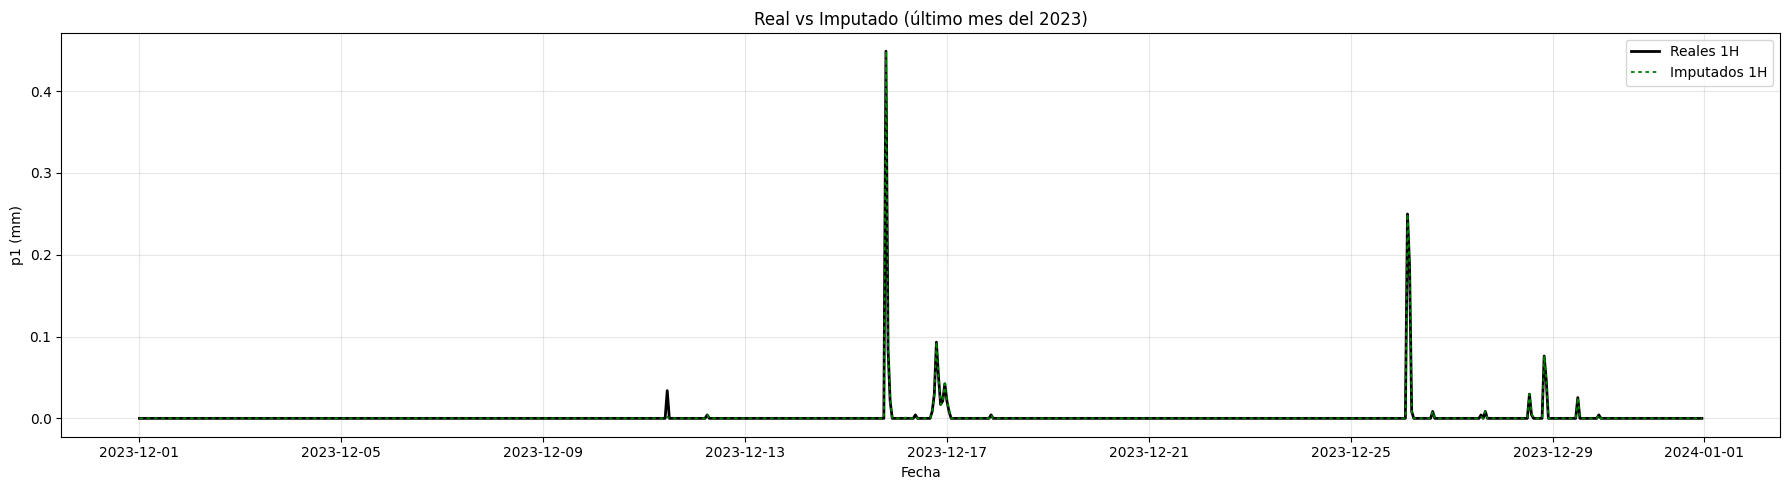

In [35]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import lightgbm as lgb
import matplotlib.pyplot as plt

df = df_preprocessed.copy()

scaler = MinMaxScaler()
df["p1_scaled"] = scaler.fit_transform(df[["p1"]])

window = 15
X, y = [], []
indices_target = []

for i in range(window, len(df)):

    if df["calidad"].iloc[i] != 0:
        continue

    past_q = df["calidad"].iloc[i-window:i].values

    if np.any(past_q != 1):
        continue

    X.append(df["p1_scaled"].iloc[i-window:i].values)

    y.append(df["p1_scaled"].iloc[i])

    indices_target.append(df.index[i])

X = np.array(X)
y = np.array(y)

print(f"Total ventanas limpias creadas: {len(X)}")

feature_names = [f"f{i}" for i in range(window)]
X_df = pd.DataFrame(X, columns=feature_names)


n = len(X_df)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train = X_df.iloc[:train_end]
y_train = y[:train_end]

X_valid = X_df.iloc[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test = X_df.iloc[valid_end:]
y_test = y[valid_end:]

print("Train size:", len(X_train))
print("Valid size:", len(X_valid))
print("Test size :", len(X_test))


model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    device="gpu"
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)]
)


y_pred_train = model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))

y_pred_valid = model.predict(X_valid)
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
rmse_valid = sqrt(mean_squared_error(y_valid, y_pred_valid))

y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))

print("\nMétricas TRAIN")
print("MAE :", round(mae_train, 6))
print("RMSE:", round(rmse_train, 6))

print("\nMétricas VALIDATION")
print("MAE :", round(mae_valid, 6))
print("RMSE:", round(rmse_valid, 6))

print("\nMétricas TEST (independiente)")
print("MAE :", round(mae_test, 6))
print("RMSE:", round(rmse_test, 6))


if len(indices_target) > 0:

    X_imp = X_df.copy()
    imput_scaled = model.predict(X_imp)

    imput_real = scaler.inverse_transform(imput_scaled.reshape(-1, 1)).flatten()

    df["p1_imputed"] = df["p1"]
    df.loc[indices_target, "p1_imputed"] = imput_real

else:
    df["p1_imputed"] = df["p1"]

df_lightgbm = df[["p1_imputed"]].copy()
df_lightgbm.index.name = "fecha_hora"

real_1h = df["p1"].resample("1H").mean()
imp_1h = df_lightgbm["p1_imputed"].resample("1H").mean()

df_plot = pd.DataFrame({
    "real": real_1h,
    "imp": imp_1h
})

df_plot_range = df_plot.loc["2023-12-01":"2023-12-31"]

plt.figure(figsize=(18,5))
plt.plot(df_plot_range.index, df_plot_range["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_plot_range.index, df_plot_range["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))

plt.title("Real vs Imputado (último mes del 2023)")
plt.ylabel("p1 (mm)")
plt.xlabel("Fecha")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2657104167.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df_preprocessed["p1"].resample("1H").mean()
/tmp/ipython-input-2657104167.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imp_1h = df_lightgbm["p1_imputed"].resample("1H").mean()


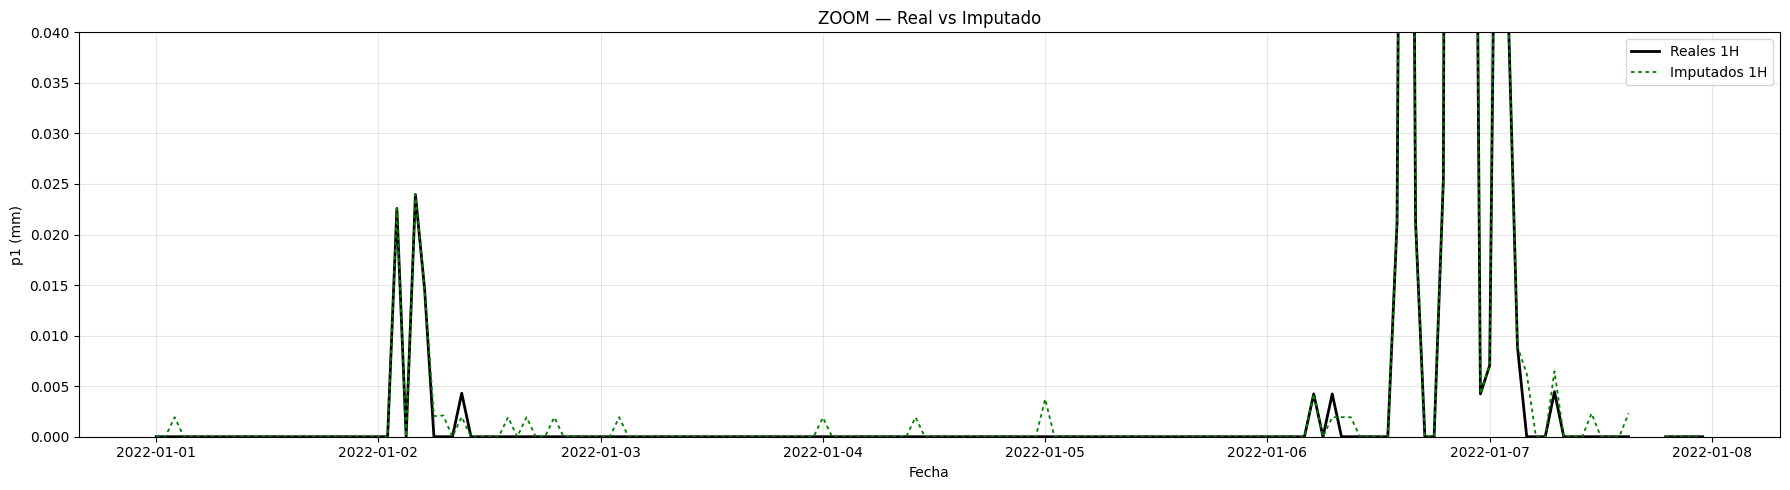

In [45]:
real_1h = df_preprocessed["p1"].resample("1H").mean()
imp_1h = df_lightgbm["p1_imputed"].resample("1H").mean()

df_plot = pd.DataFrame({
    "real": real_1h,
    "imp": imp_1h
})

df_zoom = df_plot.loc["2022-01-01":"2022-01-07"]

plt.figure(figsize=(18,5))
plt.plot(df_zoom.index, df_zoom["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_zoom.index, df_zoom["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))

plt.title("ZOOM — Real vs Imputado")
plt.ylabel("p1 (mm)")
plt.xlabel("Fecha")
plt.ylim(0, 0.04)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Imputación bidireccional

Total filas a imputar (ventanas limpias): 558


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/tmp/ipython-input-1149270686.py:121: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df["p1"].resample("1H").mean()
/tmp/ipython-input-1149270686.py:122: FutureWarning: 'H' is depre


Métricas sobre el conjunto de entrenamiento
MAE :  0.040981
RMSE: 0.071645

Métricas sobre el conjunto de validación
MAE :  0.035256
RMSE: 0.035463

Métricas sobre el conjunto de test (independiente al entrenamiento)
MAE :  0.035348
RMSE: 0.035555


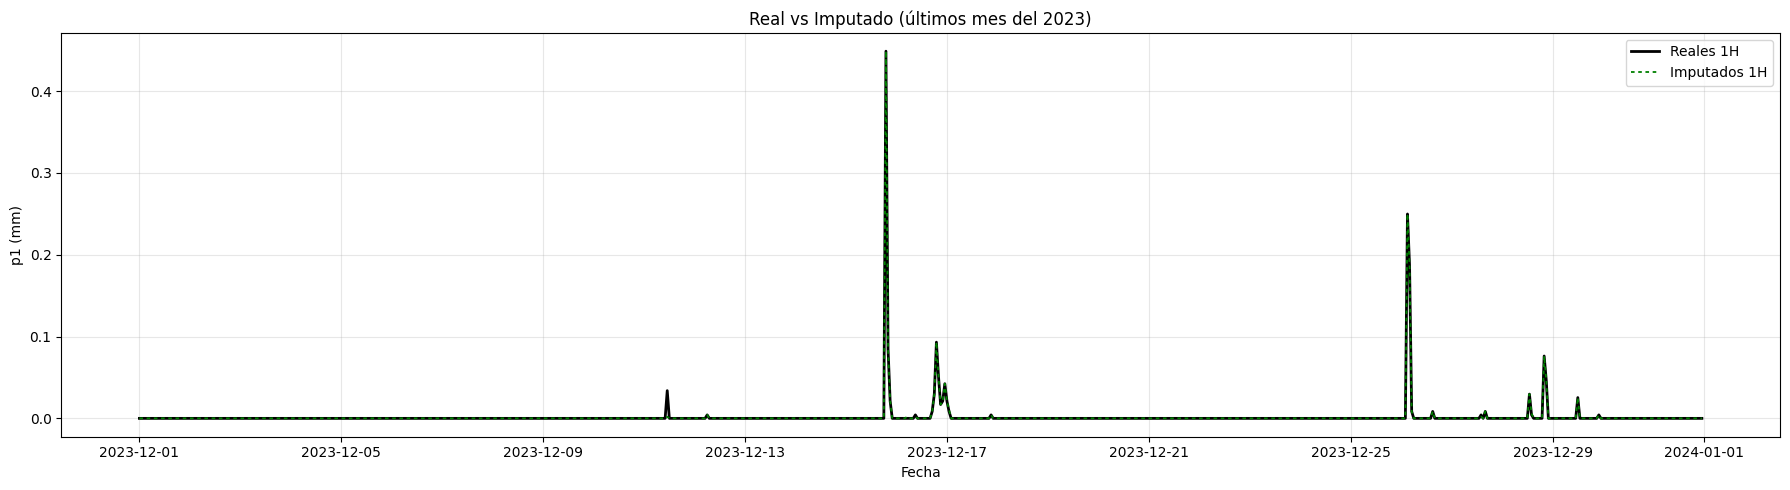

In [13]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import lightgbm as lgb
import matplotlib.pyplot as plt

df = df_preprocessed.copy()

# Escalado
scaler = MinMaxScaler()
df["p1_scaled"] = scaler.fit_transform(df[["p1"]])

window = 15

# Creación de secuencias bidireccionales limpias
X = []
y = []
indices_target = []

for i in range(window, len(df) - window):

    if df["calidad"].iloc[i] != 0:
        continue

    past_vals   = df["p1_scaled"].iloc[i-window:i].values
    past_q      = df["calidad"].iloc[i-window:i].values

    future_vals = df["p1_scaled"].iloc[i+1:i+window+1].values
    future_q    = df["calidad"].iloc[i+1:i+window+1].values

    if np.any(past_q != 1) or np.any(future_q != 1):
        continue

    seq_x = np.concatenate([past_vals, future_vals])
    seq_y = df["p1_scaled"].iloc[i]

    X.append(seq_x)
    y.append(seq_y)
    indices_target.append(df.index[i])

X = np.array(X)
y = np.array(y)

print(f"Total filas a imputar (ventanas limpias): {len(X)}")

# Train / Validation / Test Split temporal
n = len(X)

train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_valid = X[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test = X[valid_end:]
y_test = y[valid_end:]


# Modelo LightGBM
model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    device_type="gpu",
    verbosity=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
)

# Métricas de entrenamiento
y_pred_train = model.predict(X_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))

print("\nMétricas sobre el conjunto de entrenamiento")
print("MAE : ", round(mae_train, 6))
print("RMSE:", round(rmse_train, 6))


# Métricas de validación
y_pred_valid = model.predict(X_valid)
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
rmse_valid = sqrt(mean_squared_error(y_valid, y_pred_valid))

print("\nMétricas sobre el conjunto de validación")
print("MAE : ", round(mae_valid, 6))
print("RMSE:", round(rmse_valid, 6))


# Métricas de test
y_pred_test = model.predict(X_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))

print("\nMétricas sobre el conjunto de test (independiente al entrenamiento)")
print("MAE : ", round(mae_test, 6))
print("RMSE:", round(rmse_test, 6))

# Imputación
imputed_scaled = model.predict(X)
imputed_real = scaler.inverse_transform(imputed_scaled.reshape(-1, 1)).flatten()

df["p1_imputed"] = df["p1"]  # base
df.loc[indices_target, "p1_imputed"] = imputed_real

df_bidireccional = df[["p1_imputed"]].copy()
df_bidireccional.index.name = "fecha_hora"

# Gráfica
real_1h = df["p1"].resample("1H").mean()
imp_1h  = df_lightgbm["p1_imputed"].resample("1H").mean()
df_plot = pd.DataFrame({"real": real_1h, "imp": imp_1h})



# Rango específico
df_plot_range = df_plot.loc["2023-12-01":"2023-12-31"]

plt.figure(figsize=(18,5))
plt.plot(df_plot_range.index, df_plot_range["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_plot_range.index, df_plot_range["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))



plt.title("Real vs Imputado (últimos mes del 2023)")
plt.ylabel("p1 (mm)")
plt.xlabel("Fecha")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-389586041.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df_preprocessed["p1"].resample("1H").mean()
/tmp/ipython-input-389586041.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imp_1h = df_bidireccional["p1_imputed"].resample("1H").mean()


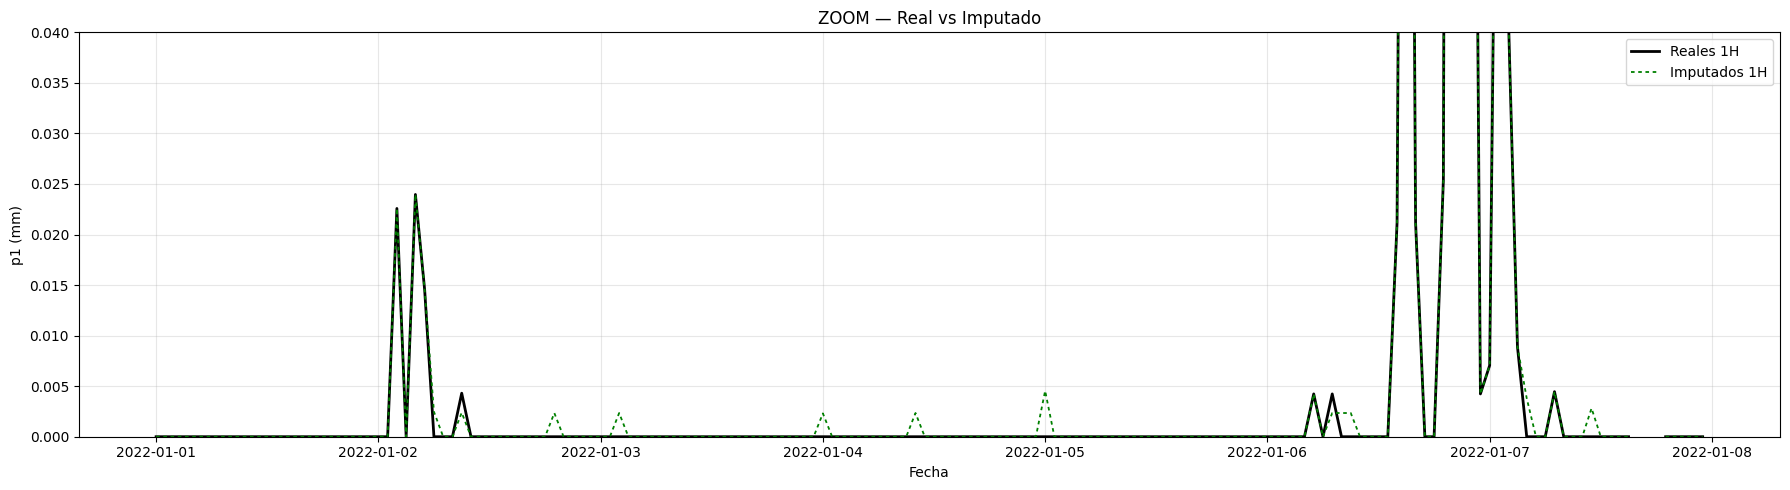

In [46]:
real_1h = df_preprocessed["p1"].resample("1H").mean()
imp_1h = df_bidireccional["p1_imputed"].resample("1H").mean()

df_plot = pd.DataFrame({
    "real": real_1h,
    "imp": imp_1h
})

df_zoom = df_plot.loc["2022-01-01":"2022-01-07"]

plt.figure(figsize=(18,5))
plt.plot(df_zoom.index, df_zoom["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_zoom.index, df_zoom["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))

plt.title("ZOOM — Real vs Imputado")
plt.ylabel("p1 (mm)")
plt.xlabel("Fecha")
plt.ylim(0, 0.04)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Imputación LSTM

gpu detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
total filas a imputar (ventanas limpias): 740
Train size : 518
Valid size : 111
Test size  : 111
Epoch 1/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 0.0059 - val_loss: 0.0039
Epoch 2/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0040
Epoch 3/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0048 - val_loss: 0.0041
Epoch 4/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0039
Epoch 5/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0058 - val_loss: 0.0039
Epoch 6/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0080 - val_loss: 0.0042
Epoch 7/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0051 - val_loss: 0.0041
Epoch 8/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0040 - val_loss: 0.0039
Epoch 9/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0067 - val_loss: 0.0041
Epoch 10/40
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.004

/tmp/ipython-input-21963601.py:131: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df["p1"].resample("1H").mean()
/tmp/ipython-input-21963601.py:132: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imp_1h  = df_lstm["p1_imputed"].resample("1H").mean()


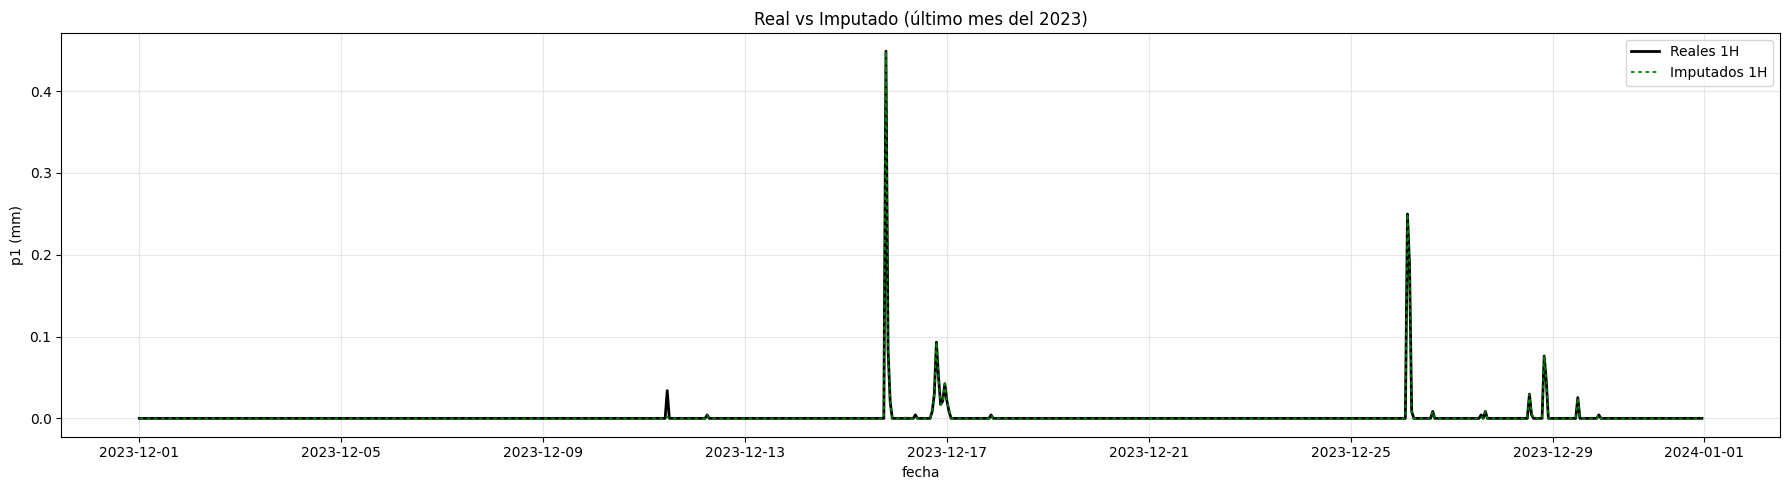

In [14]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

# confirmar gpu
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("gpu detectada:", gpus)
else:
    print("gpu no detectada — la lstm será más lenta")

# copia base
df = df_preprocessed.copy()

# escalado solo para el modelo
scaler = MinMaxScaler()
df["p1_scaled"] = scaler.fit_transform(df[["p1"]])

window = 15   # tamaño ventana

# creación de secuencias (solo pasado, ventanas limpias)
X = []
y = []
indices_target = []

for i in range(window, len(df)):

    if df["calidad"].iloc[i] != 0:
        continue

    past_vals = df["p1_scaled"].iloc[i-window:i].values
    past_q    = df["calidad"].iloc[i-window:i].values

    if np.any(past_q != 1):
        continue

    X.append(past_vals.reshape(-1, 1))
    y.append(df["p1_scaled"].iloc[i])
    indices_target.append(df.index[i])

X = np.array(X)
y = np.array(y)

print(f"total filas a imputar (ventanas limpias): {len(X)}")

# train / valid / test split temporal
n = len(X)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train = X[:train_end]
y_train = y[:train_end]

X_valid = X[train_end:valid_end]
y_valid = y[train_end:valid_end]

X_test  = X[valid_end:]
y_test  = y[valid_end:]

print("Train size :", len(X_train))
print("Valid size :", len(X_valid))
print("Test size  :", len(X_test))

# modelo lstm
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=False),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse"
)

history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

# métricas de validación
# métricas de entrenamiento
y_pred_train = model.predict(X_train).flatten()
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = sqrt(mean_squared_error(y_train, y_pred_train))

print("\nMétricas sobre el conjunto de entrenamiento")
print("MAE :", round(mae_train, 6))
print("RMSE:", round(rmse_train, 6))

# métricas de validación
y_pred_valid = model.predict(X_valid).flatten()
mae_valid = mean_absolute_error(y_valid, y_pred_valid)
rmse_valid = sqrt(mean_squared_error(y_valid, y_pred_valid))

print("\nMétricas sobre el conjunto de validación")
print("MAE :", round(mae_valid, 6))
print("RMSE:", round(rmse_valid, 6))

# métricas de test
y_pred_test = model.predict(X_test).flatten()
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = sqrt(mean_squared_error(y_test, y_pred_test))

print("\nMétricas sobre el conjunto de test (independiente al entrenamiento)")
print("MAE :", round(mae_test, 6))
print("RMSE:", round(rmse_test, 6))


# imputación final
imputed_scaled = model.predict(X).flatten()
imputed_real = scaler.inverse_transform(imputed_scaled.reshape(-1, 1)).flatten()

df["p1_imputed"] = df["p1"]
df.loc[indices_target, "p1_imputed"] = imputed_real

# dataframe final (equivalente a los otros métodos)
df_lstm = df[["p1_imputed"]].copy()
df_lstm.index.name = "fecha_hora"

print("df_lstm creado con shape:", df_lstm.shape)

# gráfica final (2023 oct – 2024 mar)
real_1h = df["p1"].resample("1H").mean()
imp_1h  = df_lstm["p1_imputed"].resample("1H").mean()

df_plot = pd.DataFrame({"real": real_1h, "imp": imp_1h})
df_plot_range = df_plot.loc["2023-12-01":"2023-12-31"]

plt.figure(figsize=(18,5))
plt.plot(df_plot_range.index, df_plot_range["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_plot_range.index, df_plot_range["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))

plt.title("Real vs Imputado (último mes del 2023)")
plt.ylabel("p1 (mm)")
plt.xlabel("fecha")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2150975458.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  real_1h = df_preprocessed["p1"].resample("1H").mean()
/tmp/ipython-input-2150975458.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  imp_1h = df_lstm["p1_imputed"].resample("1H").mean()


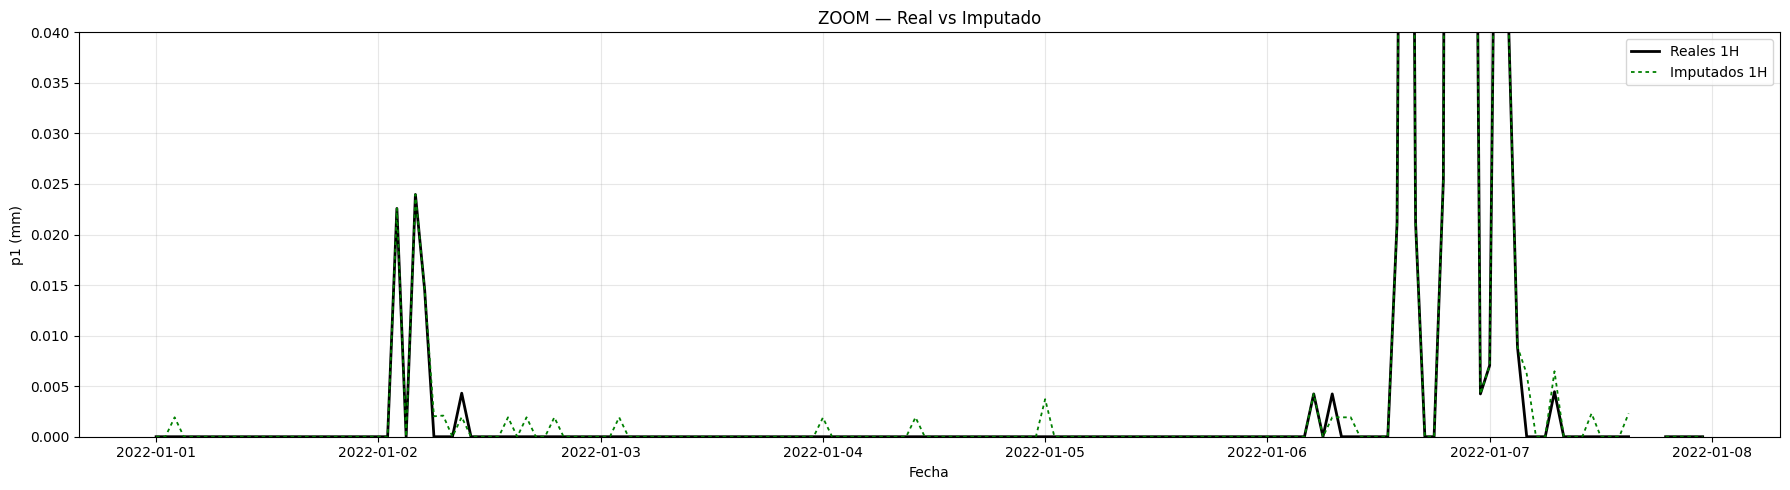

In [44]:
real_1h = df_preprocessed["p1"].resample("1H").mean()
imp_1h = df_lstm["p1_imputed"].resample("1H").mean()

df_plot = pd.DataFrame({
    "real": real_1h,
    "imp": imp_1h
})

# --- ZOOM ---
df_zoom = df_plot.loc["2022-01-01":"2022-01-07"]

plt.figure(figsize=(18,5))
plt.plot(df_zoom.index, df_zoom["real"],
         label="Reales 1H",
         linewidth=2,
         color="black")

plt.plot(df_zoom.index, df_zoom["imp"],
         label="Imputados 1H",
         linewidth=1.3,
         color="green",
         dashes=(2, 2))

plt.title("ZOOM — Real vs Imputado")
plt.ylabel("p1 (mm)")
plt.xlabel("Fecha")
plt.ylim(0, 0.04)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## **3) Forecasting**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


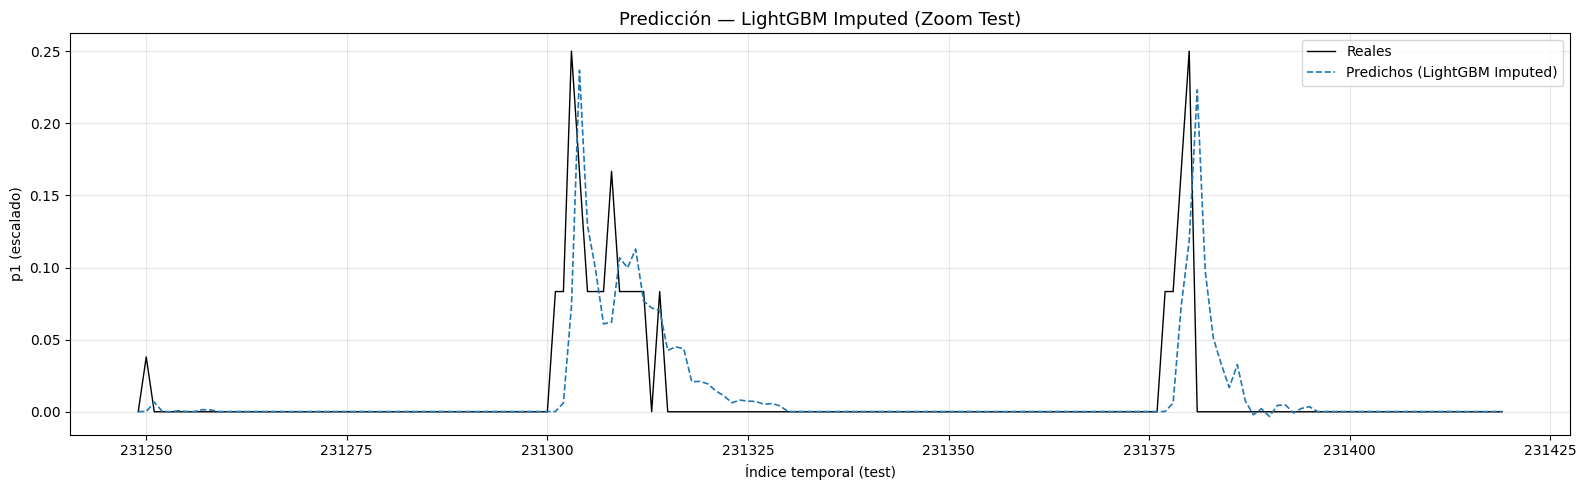

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


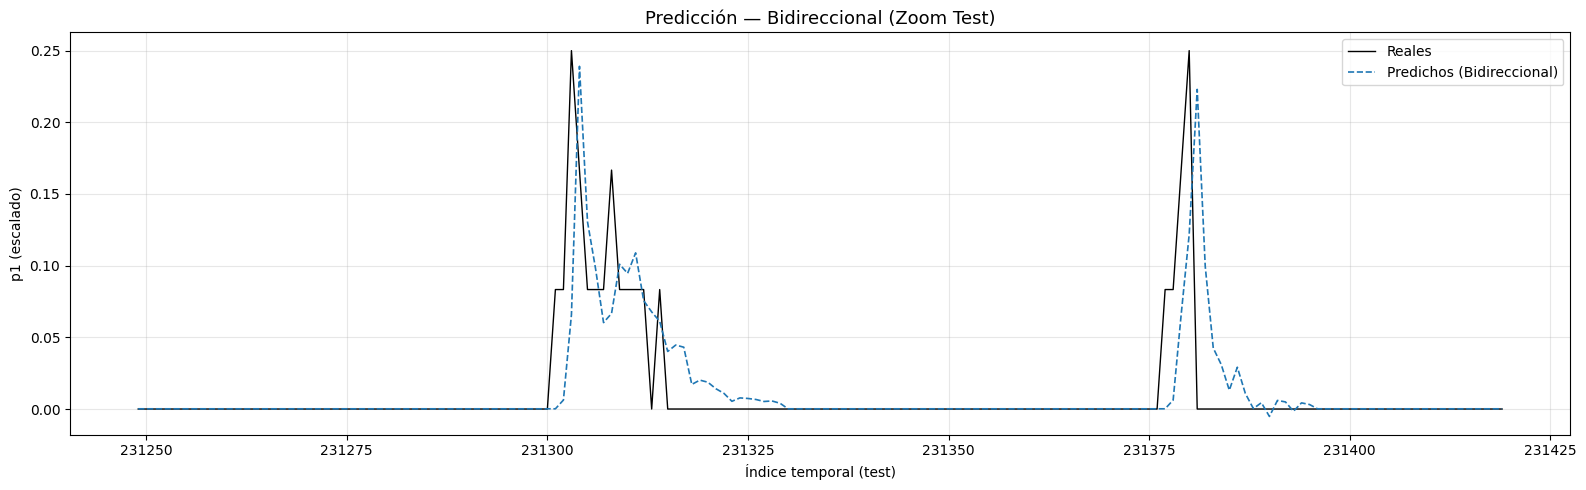

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


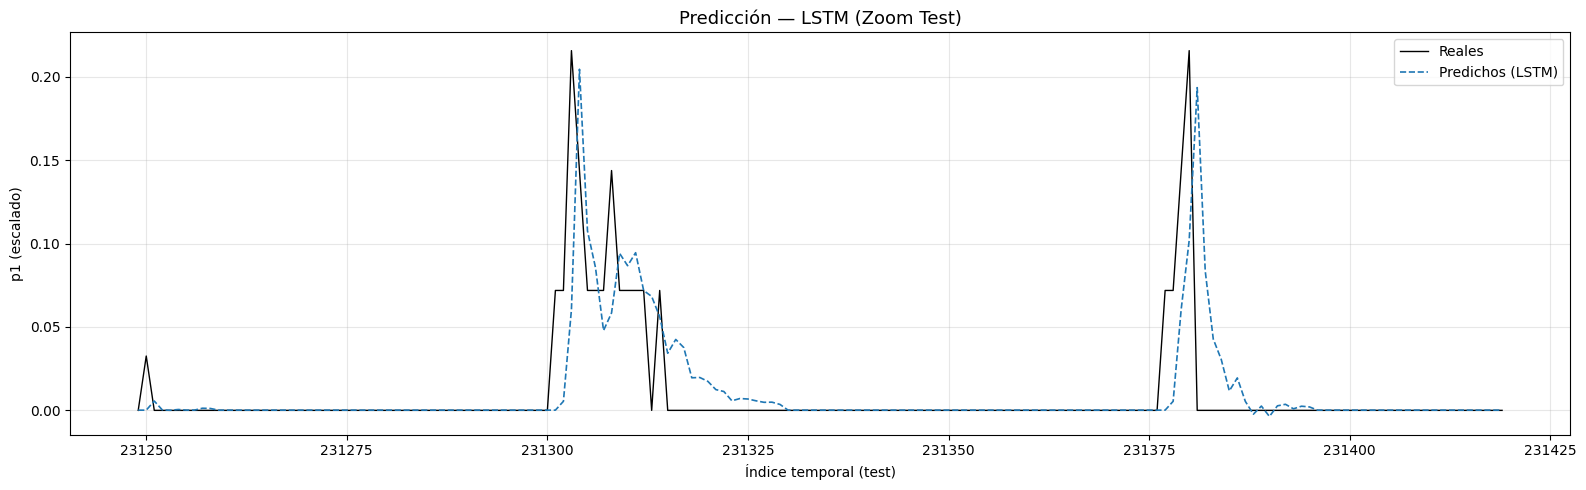


MÉTRICAS COMPARATIVAS

                       MAE      RMSE
LightGBM Imputed  0.001152  0.008075
Bidireccional     0.001161  0.008243
LSTM              0.000993  0.006964


In [15]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import lightgbm as lgb
import matplotlib.pyplot as plt

def run_forecast(df_input, name, window=15, zoom_size=500):
    df = df_input.copy()
    df = df.sort_index()

    # Escalar p1_imputed
    scaler = MinMaxScaler()
    df["p1_scaled"] = scaler.fit_transform(df[["p1_imputed"]])

    # Crear secuencias
    X, y = [], []

    for i in range(window, len(df)):
        seq_x = df["p1_scaled"].iloc[i-window:i].values
        seq_y = df["p1_scaled"].iloc[i]
        X.append(seq_x)
        y.append(seq_y)

    X = np.array(X)
    y = np.array(y)

# split training / validation / test
    N = len(X)

    train_end = int(N * 0.70)
    valid_end = int(N * 0.85)

    X_train = X[:train_end]
    y_train = y[:train_end]

    X_valid = X[train_end:valid_end]
    y_valid = y[train_end:valid_end]

    X_test = X[valid_end:]
    y_test = y[valid_end:]

# modelo de forecasting
    model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        max_depth=-1,
        device="gpu"
    )

    model.fit(X_train, y_train,
              eval_set=[(X_valid, y_valid)],
              eval_metric="l1")

    # Predicción test
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))


    start = max(0, len(y_test) - zoom_size)
    end = 231420

    plt.figure(figsize=(16, 5))
    plt.plot(range(start, end), y_test[start:end],
             label="Reales", color="black", linewidth=1)
    plt.plot(range(start, end), y_pred[start:end],
             "--", label=f"Predichos ({name})", linewidth=1.2)

    plt.title(f"Predicción — {name} (Zoom Test)", fontsize=13)
    plt.xlabel("Índice temporal (test)")
    plt.ylabel("p1 (escalado)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return mae, rmse


results = {}

results["LightGBM Imputed"] = run_forecast(df_lightgbm, "LightGBM Imputed")
results["Bidireccional"]    = run_forecast(df_bidireccional, "Bidireccional")
results["LSTM"]             = run_forecast(df_lstm, "LSTM")


df_results = pd.DataFrame(results, index=["MAE", "RMSE"]).T
print("\nMÉTRICAS COMPARATIVAS\n")
print(df_results.round(6))
